<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 30 · Part VI Probability</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Probability Fundamentals 🎲</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:720px;line-height:1.6">The language of uncertainty, made concrete. We build sample spaces, assign probabilities three different ways, and watch the Law of Large Numbers turn randomness into reliable proportions.</div>
  <div style="margin-top:16px;font-size:13px;color:#cbd5e1">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from itertools import product
rng = np.random.default_rng(30)
BLUE="#2563eb"; INDIGO="#4f46e5"; CYAN="#0891b2"; AMBER="#d97706"; GREEN="#059669"; PURPLE="#7c3aed"; PINK="#db2777"; INK="#1a2138"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
print("ready")

ready


<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#4f46e5;letter-spacing:1px">DEMO 1 · SAMPLE SPACE</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Experiments, outcomes, events</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">A <b>random experiment</b> has uncertain outcomes; the <b>sample space</b> is the set of all of them; an <b>event</b> is any subset. Let us build the sample space of rolling two dice and pick out a few events.</div>
</div>

In [2]:
sample_space = list(product(range(1,7), range(1,7)))
print("rolling two dice -> sample space size:", len(sample_space))
print("first few outcomes:", sample_space[:5])

# events are subsets of the sample space
sum7      = [o for o in sample_space if sum(o)==7]
doubles   = [o for o in sample_space if o[0]==o[1]]
sum_gt9   = [o for o in sample_space if sum(o)>9]
print("\nevent {sum = 7}   :", len(sum7), "outcomes ->", sum7)
print("event {doubles}   :", len(doubles), "outcomes")
print("event {sum > 9}   :", len(sum_gt9), "outcomes")

rolling two dice -> sample space size: 36
first few outcomes: [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5)]

event {sum = 7}   : 6 outcomes -> [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)]
event {doubles}   : 6 outcomes
event {sum > 9}   : 6 outcomes


**Vocabulary in one place:** the *experiment* is "roll two dice", the *sample space* is the 36 equally likely ordered pairs, and an *event* like "the sum is 7" is just the subset of outcomes that make it true (here, 6 of them). Everything in probability is built on these three words.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 2 · CLASSICAL PROBABILITY</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">Count favorable over total</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">When every outcome is equally likely, <b>classical probability</b> is simply favorable outcomes divided by total outcomes. The distribution of the two-dice sum is the classic example.</div>
</div>

P(sum = k) for two dice:
    2: 1/36 = 0.028
    3: 2/36 = 0.056
    4: 3/36 = 0.083
    5: 4/36 = 0.111
    6: 5/36 = 0.139
    7: 6/36 = 0.167
    8: 5/36 = 0.139
    9: 4/36 = 0.111
   10: 3/36 = 0.083
   11: 2/36 = 0.056
   12: 1/36 = 0.028


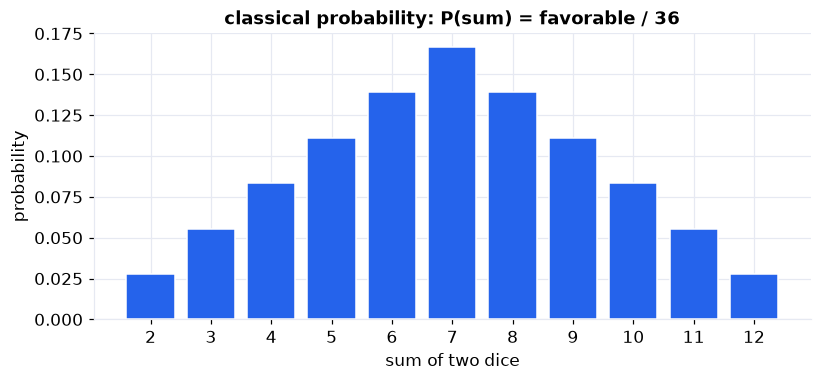


most likely sum is 7 (P = 6/36 = 0.167); 2 and 12 are rarest (1/36 each).


In [3]:
totals = [sum(o) for o in sample_space]
dist = pd.Series(totals).value_counts().sort_index()
prob = (dist/36).round(3)
print("P(sum = k) for two dice:")
for k in dist.index: print(f"   {k:>2}: {dist[k]}/36 = {prob[k]:.3f}")

fig, ax = plt.subplots(figsize=(7.5,3.6))
ax.bar(dist.index, dist.values/36, color=BLUE, edgecolor="white")
ax.set_xticks(range(2,13)); ax.set_xlabel("sum of two dice"); ax.set_ylabel("probability")
ax.set_title("classical probability: P(sum) = favorable / 36"); plt.tight_layout(); plt.show()
print("\nmost likely sum is 7 (P = 6/36 = 0.167); 2 and 12 are rarest (1/36 each).")

**Why 7 is special:** there are more ways to make 7 (six of them) than any other total, so it is the most probable. Classical probability needs no experiment at all, just careful counting of a sample space whose outcomes are equally likely.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 3 · EMPIRICAL PROBABILITY</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">The Law of Large Numbers</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6"><b>Empirical probability</b> is the long-run relative frequency from actually running the experiment. The <b>Law of Large Numbers</b> says it converges to the theoretical value as trials pile up. Watch a coin and a die settle down.</div>
</div>

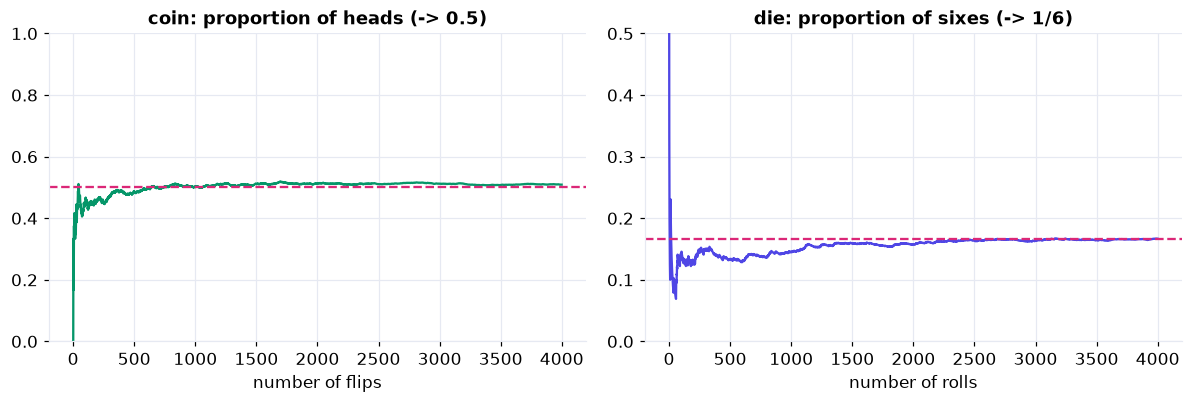

after 4000 flips: P(heads) approx 0.509  (theory 0.500)
after 4000 rolls: P(six)   approx 0.167  (theory 0.167)


In [4]:
N = 4000
flips = rng.integers(0, 2, N)            # 1 = heads
run_heads = np.cumsum(flips) / np.arange(1, N+1)
rolls = rng.integers(1, 7, N)
run_six   = np.cumsum(rolls==6) / np.arange(1, N+1)

fig, ax = plt.subplots(1, 2, figsize=(11,3.8))
ax[0].plot(run_heads, color=GREEN); ax[0].axhline(0.5, ls="--", color=PINK)
ax[0].set_title(f"coin: proportion of heads (-> 0.5)"); ax[0].set_xlabel("number of flips"); ax[0].set_ylim(0,1)
ax[1].plot(run_six, color=INDIGO); ax[1].axhline(1/6, ls="--", color=PINK)
ax[1].set_title("die: proportion of sixes (-> 1/6)"); ax[1].set_xlabel("number of rolls"); ax[1].set_ylim(0,0.5)
plt.tight_layout(); plt.show()
print(f"after {N} flips: P(heads) approx {run_heads[-1]:.3f}  (theory 0.500)")
print(f"after {N} rolls: P(six)   approx {run_six[-1]:.3f}  (theory {1/6:.3f})")

**Theory and experiment meet.** Early on the proportion swings wildly; as trials accumulate it homes in on the theoretical probability. This convergence, first proved by Jacob Bernoulli (*Ars Conjectandi*, 1713), is why a casino is happy to gamble: in the long run the proportions are dependable, even though any single play is not.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 4 · THE SCALE & COMPLEMENT</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">From 0 to 1, and its mirror</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">Every probability lives between <b>0 (impossible)</b> and <b>1 (certain)</b>. The <b>complement rule</b>, P(not A) = 1 - P(A), is often the easy way in, especially for "at least one" questions.</div>
</div>

P(no six in two rolls)      = (5/6)^2 = 0.694
P(at least one six)         = 1 - that = 0.306


empirical (100k trials)     = 0.307


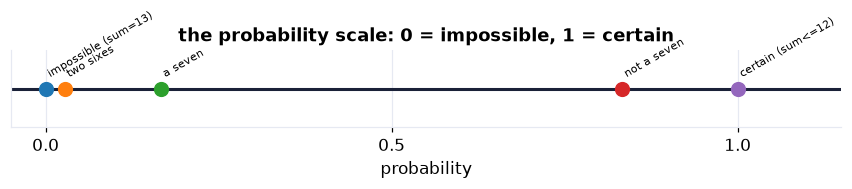

In [5]:
# P(at least one six in two rolls): the hard way vs the complement
p_no_six_one_roll = 5/6
p_at_least_one = 1 - p_no_six_one_roll**2
print(f"P(no six in two rolls)      = (5/6)^2 = {p_no_six_one_roll**2:.3f}")
print(f"P(at least one six)         = 1 - that = {p_at_least_one:.3f}")

# verify empirically
trials = rng.integers(1,7,(100_000,2))
emp = np.mean((trials==6).any(axis=1))
print(f"empirical (100k trials)     = {emp:.3f}")

events = {"impossible (sum=13)":0.0, "two sixes":1/36, "a seven":6/36,
          "not a seven":30/36, "certain (sum<=12)":1.0}
fig, ax = plt.subplots(figsize=(8,1.7))
for name,p in events.items(): ax.scatter(p, 0, s=80, zorder=3)
for name,p in events.items(): ax.annotate(name, (p,0), rotation=30, fontsize=7.5, ha="left", va="bottom", xytext=(0,6), textcoords="offset points")
ax.axhline(0, color=INK, lw=2); ax.set_xlim(-0.05,1.15); ax.set_yticks([]); ax.set_xticks([0,0.5,1])
ax.set_xlabel("probability"); ax.set_title("the probability scale: 0 = impossible, 1 = certain"); plt.tight_layout(); plt.show()

**The complement is a shortcut.** "At least one" is awkward to count directly but easy as 1 minus "none". The empirical estimate from 100,000 simulated trials lands right on the theoretical 0.306, the Law of Large Numbers again.

<div style="background:#eef2ff;border-left:5px solid #4f46e5;border-radius:10px;padding:15px 20px;font-family:Inter,sans-serif">
<span style="font-size:12px;font-weight:800;color:#db2777;letter-spacing:1px">DEMO 5 · THE GAMBLER'S FALLACY</span>
<div style="font-size:20px;font-weight:800;color:#1a2138;margin-top:3px">A coin has no memory</div>
<div style="color:#4a5578;margin-top:6px;line-height:1.6">After five heads in a row, is tails "due"? No. Independent events do not self-correct. We test it: look at every flip that follows a run of heads, and check how often the next flip is heads.</div>
</div>

In [6]:
flips = rng.integers(0,2,200_000)        # 1 = heads
# find positions right after a run of >=3 consecutive heads
after_streak = []
streak = 0
for i in range(len(flips)-1):
    streak = streak+1 if flips[i]==1 else 0
    if streak >= 3:
        after_streak.append(flips[i+1])
after_streak = np.array(after_streak)
print(f"flips following a run of >=3 heads: {len(after_streak):,}")
print(f"proportion that were ALSO heads  : {after_streak.mean():.3f}")
print("theory: still 0.500 -- the coin does not remember the streak.")

flips following a run of >=3 heads: 24,950
proportion that were ALSO heads  : 0.500
theory: still 0.500 -- the coin does not remember the streak.


**The fallacy, debunked.** Even right after a long streak of heads, the next flip is heads about half the time. Past independent results carry no information about the next one. Confusing "rare in the long run" with "due now" is one of the most common and costly misreadings of probability.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">🎯 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:8px">
<li><b>Experiment, sample space, event</b>, the three words everything is built on.</li>
<li><b>Classical</b> probability counts favorable / total; <b>empirical</b> probability measures long-run frequency; both agree as trials grow (<b>Law of Large Numbers</b>).</li>
<li>Probabilities live on <b>[0, 1]</b>; the <b>complement</b> 1 - P(A) is the shortcut for "at least one".</li>
<li>Independent events have <b>no memory</b>: the gambler's fallacy is a fallacy.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>